In [29]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [30]:
df = pd.read_csv('/workspaces/SML/SML /Exp 10/temps.csv')

In [31]:
df.head()

,year,month,day,week,temp_2,temp_1,average,actual,friend
0,2019,1,1,Fri,45,45,45.6,45,29
1,2019,1,2,Sat,44,45,45.7,44,61
2,2019,1,3,Sun,45,44,45.8,41,56
3,2019,1,4,Mon,44,41,45.9,40,53
4,2019,1,5,Tues,41,40,46.0,44,41


ONE HOT ENCODING

In [32]:
df =pd.get_dummies(df)
df.head(5)

,year,month,day,temp_2,temp_1,average,actual,friend,week_Fri,week_Mon,week_Sat,week_Sun,week_Thurs,week_Tues,week_Wed
0,2019,1,1,45,45,45.6,45,29,True,False,False,False,False,False,False
1,2019,1,2,44,45,45.7,44,61,False,False,True,False,False,False,False
2,2019,1,3,45,44,45.8,41,56,False,False,False,True,False,False,False
3,2019,1,4,44,41,45.9,40,53,False,True,False,False,False,False,False
4,2019,1,5,41,40,46.0,44,41,False,False,False,False,False,True,False


In [33]:
print('Shape of features after one-hot encoding',df.shape)

Shape of features after one-hot encoding (348, 15)


In [34]:
import numpy as np

# 1. Extract labels
labels = np.array(df['actual'])

# 2. Remove labels from features
# Note: It's often safer to assign to a new variable like 'features'
df = df.drop('actual', axis=1)

# 3. Save column names for later (e.g., feature importance plots)
df_list = list(df.columns)

# 4. Convert DataFrame to NumPy array
# This replaces the broken 'df.array(df)' line
df = df.to_numpy() 

# Now 'df' is a 2D array ready for machine learning

In [35]:
from sklearn.model_selection import train_test_split
#split the data into train and test set
train_features,test_features,train_labels,test_labels = train_test_split(df,labels,test_size=0.25,random_state=42)

In [36]:
print(train_features.shape)
print(train_labels.shape)
print(test_features.shape)
print(test_labels.shape)

(261, 14)
(261,)
(87, 14)
(87,)


In [37]:
from sklearn.ensemble import RandomForestRegressor
rf = RandomForestRegressor(n_estimators=100,random_state=42)
rf.fit(train_features,train_labels)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsample

In [38]:
rf_new = RandomForestRegressor(n_estimators=100,criterion='mse',max_depth=None,min_samples_split=2,min_samples_leaf=1)

In [39]:
#use the forest's predict method
prediction = rf.predict(test_features)

In [40]:
import pydot

# To check if it's working correctly:
print(pydot.__version__)

4.0.1


In [45]:
from sklearn.tree import export_graphviz
import os

# Update this path to where your Graphviz 'bin' folder is located
# On Windows, it's usually something like this:
os.environ["PATH"] += os.pathsep + '/workspaces/SML/SML /Exp 10'


import pydot
tree = rf.estimators_[5]
#export the image to a dot file
export_graphviz(tree,out_file='tree.dot',feature_names=df_list,rounded=True,precision=1)

#use dot file to create graph

(graph, ) = pydot.graph_from_dot_file('tree.dot')

graph.write_png('tree.png')

In [46]:
tree.tree_.max_depth

15

In [47]:
from sklearn.tree import export_graphviz
import pydot

rf_small=RandomForestRegressor(n_estimators=10,max_depth=3,random_state=42)
rf_small.fit(train_features,train_labels)
tree_small=rf_small.estimators_[5]

export_graphviz(tree_small,out_file='small_tree.dot',feature_names=df_list,rounded=True,precision=1)
(graph,)=pydot.graph_from_dot_file('small_tree.dot')
graph.write_png('small_tree.png');

In [48]:
importances=list(rf.feature_importances_)
feature_importances=[(feature,round(importance,2)) for feature,importance in zip(df_list,importances)]
feature_importances=sorted(feature_importances,key=lambda x:x[1],reverse=True)
[print ('Variable: {:20} Importance: {}'.format(*pair)) for pair in feature_importances];

Variable: temp_1               Importance: 0.73
Variable: average              Importance: 0.17
Variable: day                  Importance: 0.02
Variable: temp_2               Importance: 0.02
Variable: friend               Importance: 0.02
Variable: month                Importance: 0.01
Variable: week_Sat             Importance: 0.01
Variable: year                 Importance: 0.0
Variable: week_Fri             Importance: 0.0
Variable: week_Mon             Importance: 0.0
Variable: week_Sun             Importance: 0.0
Variable: week_Thurs           Importance: 0.0
Variable: week_Tues            Importance: 0.0
Variable: week_Wed             Importance: 0.0


Text(0.5, 0, 'Variable')

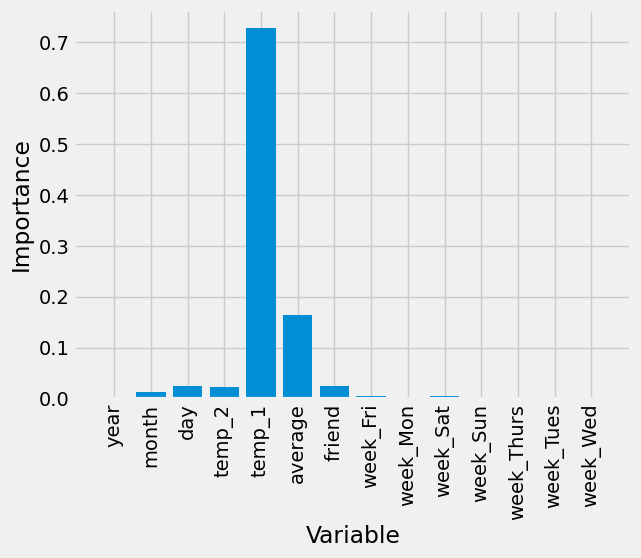

In [49]:
import matplotlib.pyplot as plt
%matplotlib inline
plt.style.use('fivethirtyeight')
x_values=list(range(len(importances)))
plt.bar(x_values,importances,orientation='vertical')
plt.xticks(x_values,df_list,rotation='vertical')
plt.ylabel('Importance')
plt.xlabel('Variable')

In [51]:
import datetime

months = df[:,df_list.index('month')]
days = df[:,df_list.index('day')]   
years = df[:,df_list.index('year')]

dates = [str(int(year)) + '-' + str(int(month)) + '-' + str(int(day)) for year, month, day in zip(years, months, days)]
dates = [datetime.datetime.strptime(date, '%Y-%m-%d') for date in dates]

true_data = pd.DataFrame(data = {'date': dates, 'actual': labels})

months_test = test_features[:, df_list.index('month')]
days_test = test_features[:, df_list.index('day')]
years_test = test_features[:, df_list.index('year')]

dates_test = [str(int(year)) + '-' + str(int(month)) + '-' + str(int(day)) for year, month, day in zip(years_test, months_test, days_test)]
dates_test = [datetime.datetime.strptime(date, '%Y-%m-%d') for date in dates_test]

predicted_data = pd.DataFrame(data={'date': dates_test, 'predicted': prediction})

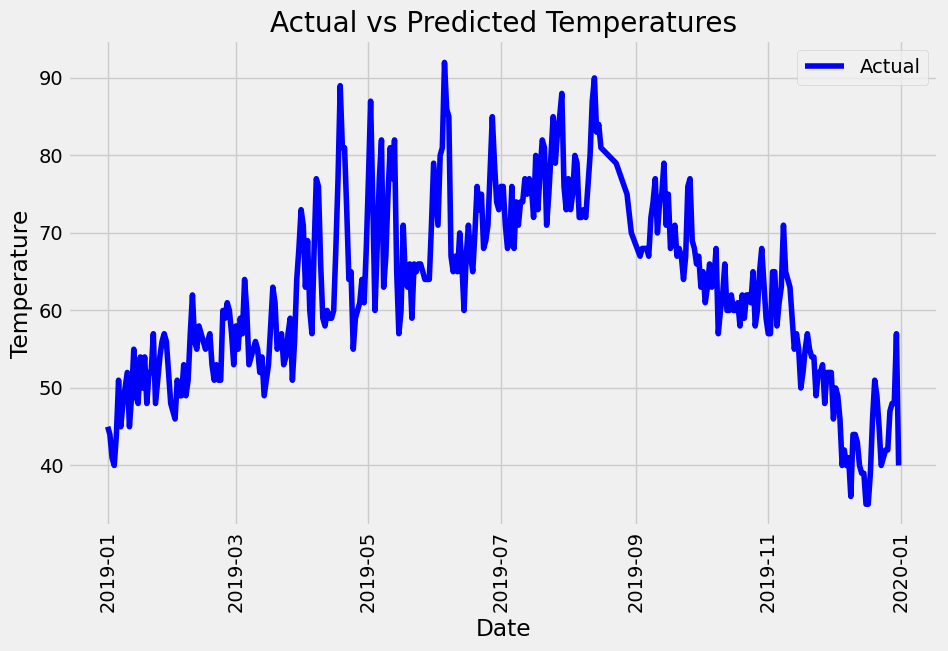

In [54]:
#plot the actual values
plt.figure(figsize=(10, 6))
plt.plot(true_data['date'], true_data['actual'], 'b-',label='Actual')
plt.xlabel('Date')
plt.ylabel('Temperature')
plt.title('Actual vs Predicted Temperatures')
plt.xticks(rotation='vertical')
plt.legend()
plt.show()